In [ ]:
# 1. Data Loading and Exploration
# 2. Data Visualization
# 3. Statistical Analysis
# 4. Hypothesis Testing


In [38]:
# 1. Data Loading and Exploration

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

stocks = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')

stocks.info()

print(stocks.head())

# cleaning na values

stocks.dropna(subset=['Close'], inplace=True)
stocks.dropna(subset=['Volume'], inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB
         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200


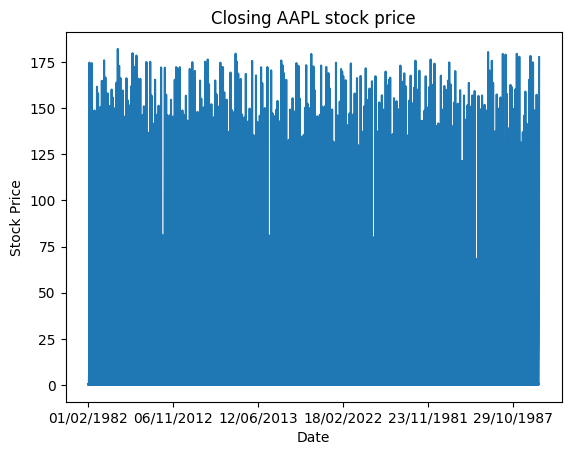

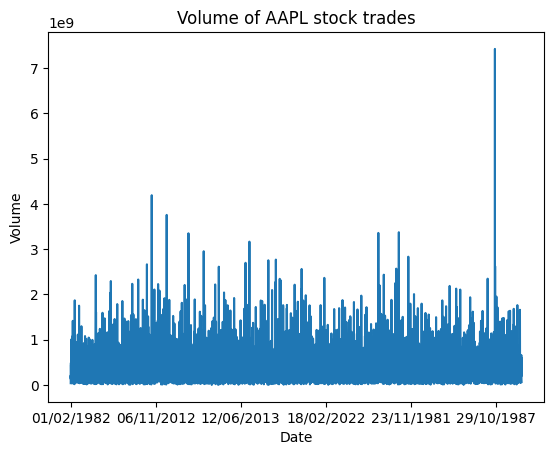

In [39]:
# 2. Data Visualization

closing_prices = stocks.groupby("Date")["Close"].sum()
volumes = stocks.groupby("Date")["Volume"].sum()

closing_prices.plot(kind="line")
plt.title("Closing AAPL stock price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

volumes.plot(kind="line")
plt.title("Volume of AAPL stock trades")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()


In [ ]:
# 3. Statistical Analysi
# Compute summary statistics (mean, median, standard deviation) for key columns.
# Analyze closing prices with a moving average.

mean_closing_prices = closing_prices.mean()
median_closing_prices = closing_prices.median()
std_closing_prices = closing_prices.std()

mean_volumes = volumes.mean()
median_volumes = volumes.median()
std_volumes = volumes.std()

print(f"Summary Statisstics for AAPL stock")
print(F"----------------------------------")

print(f"AAPL stock price - mean: {mean_closing_prices:.2f}, median : {median_closing_prices:.2f}, standard deviation : {std_closing_prices:.2f}")
print(f"Tradng volume - mean: {mean_volumes:.2f}, median: {median_volumes:.2f}, standard deviation : {std_volumes:.2f}")


Summary Statisstics for AAPL stock
----------------------------------
AAPL stock price - mean: 16.70, median : 0.49, standard deviation : 35.47
Tradng volume - mean: 327509817.26, median: 214597600.00, standard deviation : 337820279.06


In [52]:
# 4. Hypothesis Testing

from scipy.stats import f_oneway

# converting str dates to date format and grouping by years
stocks['Date'] = pd.to_datetime(stocks['Date'], format='%d/%m/%Y')
stocks['Year'] = stocks['Date'].dt.year

groups = [
    grp['Close'].values
    for _, grp in stocks.groupby('Year')
]


f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 12936.8983
P-value: 0.0000


In [ ]:
# Because P < 0.05 then average annual closing prices differ significantly across years.